# Breast Cancer Diagnosis using Machine Learning

---

## Project Overview

Breast cancer is one of the most common cancers affecting women worldwide and remains a leading cause of cancer-related mortality. Early diagnosis plays a critical role in improving treatment outcomes and patient survival.

In this project, multiple machine learning techniques will be developed and evaluated to classify breast tumors as **benign** or **malignant** using clinical features extracted from digitized fine needle aspiration (FNA) images.

Unlike the previous projects, this notebook places greater emphasis on **model interpretation**, **feature selection**, **validation techniques**, and **explainable artificial intelligence (XAI)** in addition to predictive performance.

---

## Learning Outcomes

By the end of this project, I will be able to:

- Understand the clinical background of breast cancer diagnosis.
- Perform advanced exploratory data analysis.
- Identify relationships between clinical features.
- Apply feature selection techniques.
- Train and compare multiple machine learning models.
- Understand learning curves and validation curves.
- Explain model predictions using SHAP.
- Interpret model performance from a clinical perspective.

# Clinical Importance of Early Detection

Early detection is one of the most important factors influencing breast cancer prognosis. Tumors identified at an early stage are generally smaller, less likely to have metastasized, and can often be treated with less aggressive therapies.

Machine learning has the potential to assist clinicians by identifying subtle patterns within clinical data that may be difficult to recognize manually. Such models can support early diagnosis, improve consistency in decision-making, and ultimately contribute to better patient outcomes.

In [2]:
from sklearn.datasets import load_breast_cancer

breast = load_breast_cancer()

print(breast.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


# Loading the Dataset

The Breast Cancer Wisconsin Diagnostic Dataset is included within Scikit-learn and contains measurements extracted from digitized images of fine needle aspiration (FNA) of breast masses.

Each row represents one tumor sample, while each column corresponds to a quantitative feature describing the characteristics of the cell nuclei.

The objective is to classify each tumor as **benign** or **malignant** based on these measurements.

In [3]:
import pandas as pd

# Create feature DataFrame
df = pd.DataFrame(
    breast.data,
    columns=breast.feature_names
)

# Add target column
df["target"] = breast.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Understanding the Dataset

The dataset consists of **30 numerical features** describing morphological characteristics of breast tumor cells extracted from digitized Fine Needle Aspiration (FNA) images.

These measurements capture properties such as tumor size, texture, perimeter, smoothness, compactness, symmetry, and fractal characteristics.

The target variable represents the clinical diagnosis of the tumor:

- **0 → Malignant**
- **1 → Benign**

Understanding the dataset is essential before performing exploratory data analysis or building predictive models.

In [4]:
# Dataset dimensions
df.shape

# Data types
df.info()

# Summary statistics
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# Class Distribution

Before building any machine learning model, it is important to understand the distribution of the target classes.

Class imbalance can influence model training and evaluation. If one class is much more common than the other, a model may appear to perform well simply by predicting the majority class.

Therefore, we first examine the number of benign and malignant tumors in the dataset.

In [5]:
# Count the number of samples in each class
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [6]:
# Percentage distribution
df["target"].value_counts(normalize=True) * 100

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in every machine learning project. It helps us understand the characteristics of the dataset before building predictive models.

In this section, we will:

- Examine the distribution of the target classes.
- Explore the distribution of important clinical features.
- Investigate relationships between variables.
- Identify highly correlated features.
- Gain insights that will guide feature selection and model development.

## Class Distribution

Understanding the class distribution is important because highly imbalanced datasets can bias machine learning models toward the majority class.

The following visualization illustrates the number of benign and malignant tumors in the dataset.

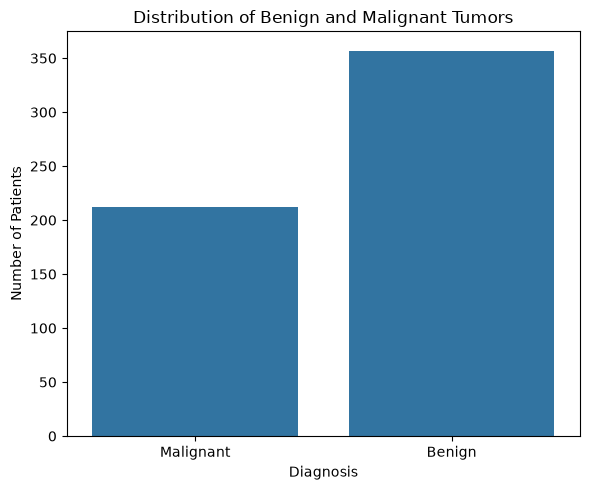

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="target"
)

plt.xticks(
    ticks=[0,1],
    labels=["Malignant", "Benign"]
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Distribution of Benign and Malignant Tumors")

plt.tight_layout()

plt.savefig(
    "../figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Pairwise Feature Relationships

Pairplots provide a visual representation of the relationships between multiple numerical features.

They are useful for identifying natural class separation, detecting correlated variables, and gaining intuition about which features may contribute most to classification.

Since the dataset contains 30 features, only a small subset of clinically meaningful variables is selected for visualization to maintain readability.

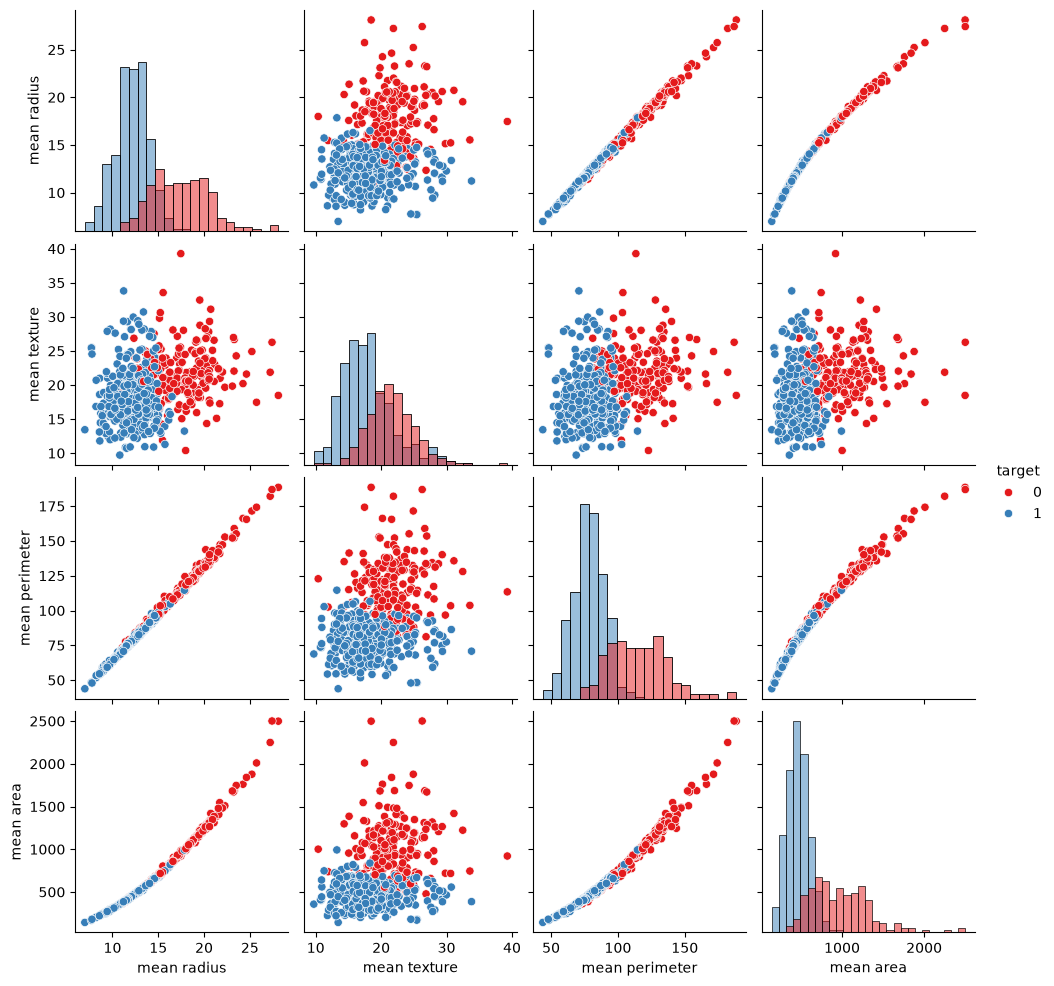

In [8]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "target"
]

sns.pairplot(
    df[selected_features],
    hue="target",
    palette="Set1",
    diag_kind="hist"
)

plt.savefig(
    "../figures/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The pairplot reveals several important characteristics of the dataset.

- Tumors with larger values for **mean radius**, **mean perimeter**, and **mean area** are more likely to be malignant.
- Benign tumors are generally clustered around smaller values for these features.
- Several feature pairs exhibit a clear separation between benign and malignant tumors, suggesting that these variables have strong predictive value.
- Strong linear relationships are also observed between **mean radius**, **mean perimeter**, and **mean area**, indicating that these features may contain overlapping information.

These observations suggest that some variables are highly informative for classification, while others may be redundant. This motivates the use of **correlation analysis** and **feature selection** in the subsequent stages of the project.